In [1]:
!pip install pylatexenc
!pip install qiskit
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 104.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 95.9 MB/s eta 0:00:00


In [6]:
import numpy as np

from qiskit import transpile
from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

import matplotlib.pyplot as plt

# =====================================================
# Step 1. Feature Map 생성
# =====================================================
feature_map = zz_feature_map(
    feature_dimension=2,
    reps=1
)

In [7]:
# =====================================================
# Step 2. Variational Circuit 생성
# =====================================================
ansatz = real_amplitudes(
    num_qubits=2,
    reps=1
)

In [8]:

# =====================================================
# Step 3. Circuit 결합
# =====================================================
qml_circuit = feature_map.compose(ansatz)


In [9]:
# =====================================================
# Step 4. Measurement 추가
# =====================================================
qml_circuit.measure_all()

In [10]:

# =====================================================
# Step 5. Parameter 확인
# =====================================================
print("Parameters")
print("---------------------------")

for p in qml_circuit.parameters:
    print(p)


Parameters
---------------------------
x[0]
x[1]
θ[0]
θ[1]
θ[2]
θ[3]


In [11]:
# =====================================================
# Step 6. Parameter 값 할당
# =====================================================
parameter_values = {
    param: np.random.random()
    for param in qml_circuit.parameters
}

bound_circuit = qml_circuit.assign_parameters(parameter_values)


Measurement Counts
---------------------------


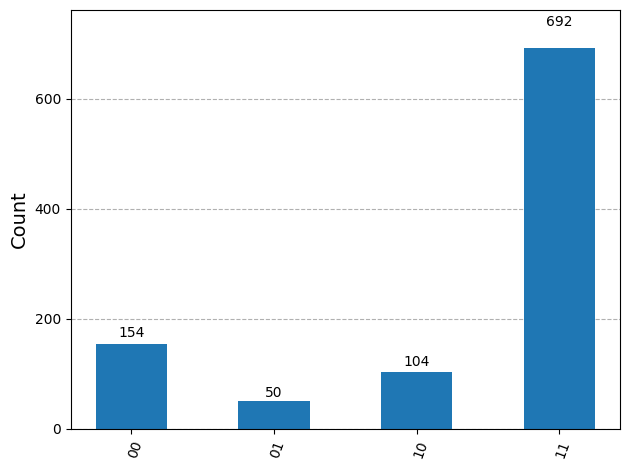

In [12]:

# =====================================================
# Step 7. Simulator 실행 - 히스토그램 시각화
# =====================================================
sim = AerSimulator()

compiled_circuit = transpile(bound_circuit, sim)

job = sim.run(compiled_circuit, shots=1000)

result = job.result()

counts = result.get_counts()

print("\nMeasurement Counts")
print("---------------------------")
fig_hist = plot_histogram(counts)
display(fig_hist)



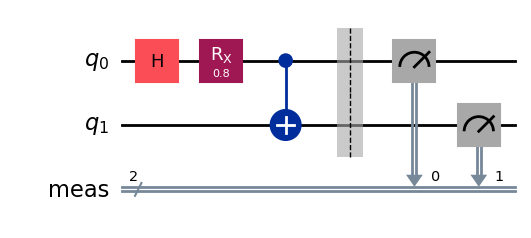

In [14]:
# =====================================================
# Step 8. 게이트 시각화
# =====================================================
fig = qc.draw("mpl")
display(fig)